In [1]:
#Step 1: Import Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [2]:
#Step 2: Load Dataset
# Load dataset
df = pd.read_csv("1_boston_housing.csv")

# Remove quotes from column names (important for your dataset)
df.columns = df.columns.str.replace('"', '')

# Display first 5 rows
df.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2


In [3]:
#Step 3: Split Features and Target
X = df.drop("MEDV", axis=1)   # Features
y = df["MEDV"]                # Target

print(X.shape, y.shape)

(506, 13) (506,)


In [4]:
#Step 4: Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [5]:
#Step 5: Feature Scaling
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [6]:
model = Sequential()
model.add(Dense(1, input_shape=(X_train.shape[1],), activation='linear'))

model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

history = model.fit(
    X_train, y_train,
    epochs=100,
    validation_split=0.05,
    verbose=1
)

Epoch 1/100


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 596.8425 - mae: 22.8421 - val_loss: 538.0823 - val_mae: 21.8782
Epoch 2/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 595.5588 - mae: 22.8289 - val_loss: 538.0802 - val_mae: 21.8793
Epoch 3/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 594.3190 - mae: 22.8165 - val_loss: 538.0331 - val_mae: 21.8798
Epoch 4/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 593.0611 - mae: 22.8022 - val_loss: 537.9591 - val_mae: 21.8791
Epoch 5/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 591.9407 - mae: 22.7915 - val_loss: 537.9750 - val_mae: 21.8815
Epoch 6/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 590.6718 - mae: 22.7774 - val_loss: 537.9233 - val_mae: 21.8814
Epoch 7/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 589.5014 - mae: 22.7650 - val_loss: 537.8741 - val_mae: 21.8811
Epoch 8/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 588.3616 - mae: 22.7530 - val_loss: 537.8725 - val_mae: 21.8821
Epoch 9/100
12/12 ━━━━━━━━━

In [15]:
# Step 6: Build a Deep Neural Network ---
model = Sequential()

# Input Layer
model.add(tf.keras.Input(shape=(X_train.shape[1],)))

# Hidden Layer 1 (64 neurons)
model.add(Dense(64, activation='relu'))

# Hidden Layer 2 (32 neurons)
model.add(Dense(32, activation='relu'))

# Output Layer (1 neuron for price)
model.add(Dense(1, activation='linear'))

model.compile(optimizer='adam', loss='mse', metrics=['mae'])

In [17]:
#Step 7: Train Model
history = model.fit(
    X_train, y_train,
    epochs=150,        # Increased from 100
    batch_size=32,
    validation_split=0.2,
    verbose=1)

Epoch 1/150
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 6.9329 - mae: 1.9378 - val_loss: 13.5724 - val_mae: 2.5678
Epoch 2/150
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 6.9127 - mae: 1.9714 - val_loss: 12.4677 - val_mae: 2.5146
Epoch 3/150
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 6.9315 - mae: 1.9588 - val_loss: 13.0755 - val_mae: 2.5342
Epoch 4/150
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 6.8060 - mae: 1.9520 - val_loss: 13.8121 - val_mae: 2.6103
Epoch 5/150
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 6.6180 - mae: 1.9105 - val_loss: 12.9417 - val_mae: 2.5122
Epoch 6/150
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 6.6469 - mae: 1.9010 - val_loss: 13.0201 - val_mae: 2.5169
Epoch 7/150
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 6.4902 - mae: 1.8912 - val_loss: 12.9779 - val_mae: 2.5156
Epoch 8/150
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 6.4538 - mae: 1.8819 - val_loss: 12.7898 - val_mae: 2.4881
Epoch 9/150
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - los

In [18]:
#Step 8: Evaluate Model
loss, mae = model.evaluate(X_test, y_test)

print("Test Loss (MSE):", loss)
print("Test MAE:", mae)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 9.5365 - mae: 2.1173 
Test Loss (MSE): 9.536520004272461
Test MAE: 2.1172828674316406


In [19]:
#Step 9: Predictions
y_pred = model.predict(X_test)

# Compare actual vs predicted
for i in range(5):
    print(f"Actual: {y_test.iloc[i]:.2f} | Predicted: {y_pred[i][0]:.2f}")

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
Actual: 23.60 | Predicted: 27.56
Actual: 32.40 | Predicted: 34.44
Actual: 13.60 | Predicted: 15.02
Actual: 22.80 | Predicted: 23.50
Actual: 16.10 | Predicted: 15.57


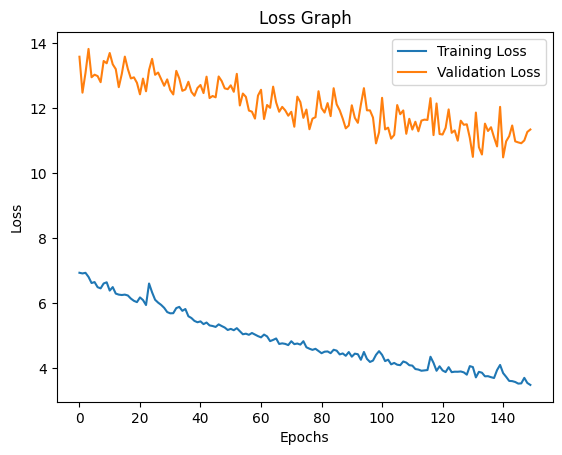

In [20]:
#Step 10: Plot Training Graphs
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title("Loss Graph")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.show()

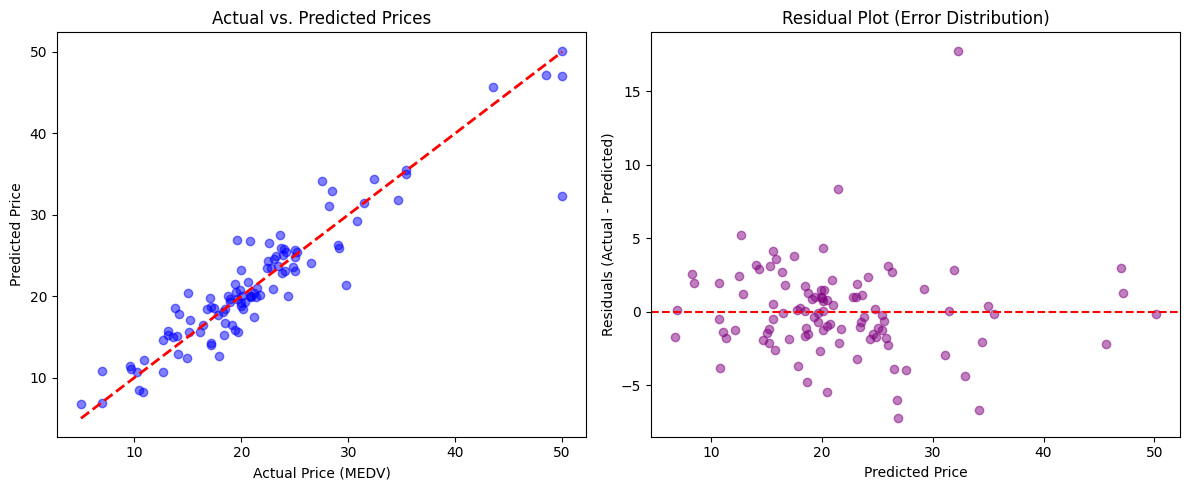

In [21]:
#step 11:Step 11: Visualization
import matplotlib.pyplot as plt
import numpy as np

# 1. Scatter Plot: Actual vs. Predicted
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(y_test, y_pred, color='blue', alpha=0.5)
# Draw a diagonal line; the closer the points are to this line, the better the model
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.title("Actual vs. Predicted Prices")
plt.xlabel("Actual Price (MEDV)")
plt.ylabel("Predicted Price")

# 2. Residual Plot: Check for patterns in error
plt.subplot(1, 2, 2)
residuals = y_test.values.reshape(-1, 1) - y_pred
plt.scatter(y_pred, residuals, color='purple', alpha=0.5)
plt.axhline(y=0, color='red', linestyle='--')
plt.title("Residual Plot (Error Distribution)")
plt.xlabel("Predicted Price")
plt.ylabel("Residuals (Actual - Predicted)")

plt.tight_layout()
plt.show()